# Chapter 4 — Sample construction and descriptive statistics

This notebook reproduces the eligibility screening, threshold sensitivity analysis, validation of the frozen 500-series sample, and the descriptive tables and figures reported in Chapter 4. Run it before the forecasting and inventory notebook. The raw M5 data are not redistributed; see the package README for setup instructions.

In [ ]:
import os
import platform
import sys
from importlib import metadata as importlib_metadata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DEFAULT_DATA_DIR = Path.home() / "Desktop" / "m5_data"
DATA_DIR = Path(
    os.environ.get("M5_DATA_DIR", str(DEFAULT_DATA_DIR))
).expanduser()
SAMPLE_FILE = Path(
    os.environ.get(
        "M5_SAMPLE_FILE",
        str(DATA_DIR / "selected_sample_ids.csv"),
    )
).expanduser()
OUTPUT_DIR = Path(
    os.environ.get(
        "CHAPTER4_OUTPUT_DIR",
        str(DATA_DIR / "chapter4_results"),
    )
).expanduser()
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

required_files = [
    DATA_DIR / "sales_train_evaluation.csv",
    DATA_DIR / "calendar.csv",
    DATA_DIR / "sell_prices.csv",
    SAMPLE_FILE,
]
missing_files = [path for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Missing required files:\n"
        + "\n".join(str(path) for path in missing_files)
    )


def installed_version(distribution_name):
    try:
        return importlib_metadata.version(distribution_name)
    except importlib_metadata.PackageNotFoundError:
        return "not installed"


print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("NumPy:", installed_version("numpy"))
print("pandas:", installed_version("pandas"))
print("matplotlib:", installed_version("matplotlib"))
print("Data directory:", DATA_DIR)
print("Sample file:", SAMPLE_FILE)
print("Output directory:", OUTPUT_DIR)

In [5]:
SELECTION_END = 1829

In [7]:
# Baseline eligibility rules from Chapter 3.
MIN_ACTIVE_DAYS = 730
MIN_POSITIVE_DAYS = 10
RECENT_ACTIVITY_DAYS = 90

# Demand-class boundaries.
ADI_LIMIT = 1.32
CV2_LIMIT = 0.49

In [9]:
sales = pd.read_csv(DATA_DIR / "sales_train_evaluation.csv")
calendar = pd.read_csv(DATA_DIR / "calendar.csv")
prices = pd.read_csv(DATA_DIR / "sell_prices.csv")

In [10]:
calendar["day_number"] = (
    calendar["d"]
    .str.replace("d_", "", regex=False)
    .astype(int)
)

selection_days = [
    f"d_{day}" for day in range(1, SELECTION_END + 1)
]

In [13]:
print("Number of SKU-store series:", len(sales))
print("Selection period: d_1 to d_1829")

Number of SKU-store series: 30490
Selection period: d_1 to d_1829


## Active-period definition

The active period begins with the first week in which the SKU–store combination has a valid positive price.

In [17]:
# First M5 day belonging to each price week.
week_first_day = (
    calendar.groupby("wm_yr_wk")["day_number"]
    .min()
)

In [19]:
# Keep only valid positive prices.
valid_prices = prices[
    prices["sell_price"].notna()
    & (prices["sell_price"] > 0)
].copy()

In [21]:
# Convert the price week into its first M5 day.
valid_prices["price_week_first_day"] = (
    valid_prices["wm_yr_wk"].map(week_first_day)
)

In [23]:
# Do not use price information after d_1829.
valid_prices = valid_prices[
    valid_prices["price_week_first_day"] <= SELECTION_END
]

In [25]:
# Find the first valid price day for every item-store combination.
first_active_day = (
    valid_prices
    .groupby(["store_id", "item_id"], as_index=False)
    ["price_week_first_day"]
    .min()
    .rename(
        columns={"price_week_first_day": "first_active_day"}
    )
)

id_columns = [
    "id",
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",
]

series_information = sales[id_columns].copy()
series_information["row_number"] = np.arange(len(sales))

series_information = series_information.merge(
    first_active_day,
    on=["store_id", "item_id"],
    how="left",
)

series_information["has_valid_price"] = (
    series_information["first_active_day"].notna()
)

print(
    "Series with a valid price:",
    series_information["has_valid_price"].sum(),
)

Series with a valid price: 30482


## Statistics before eligibility screening

This section calculates statistics for every SKU–store series before any eligibility rule is applied.

In [29]:
sales_values = sales[selection_days].to_numpy(
    dtype=np.float32
)

positive_sales = sales_values > 0

In [31]:
# Statistics for the complete selection period d_1-d_1829.
selection_total_sales = sales_values.sum(axis=1)
selection_positive_days = positive_sales.sum(axis=1)
selection_zero_proportion = (
    (sales_values == 0).mean(axis=1)
)

has_positive_sale = positive_sales.any(axis=1)

In [33]:
# Last positive-sales day.
last_positive_day = np.where(
    has_positive_sale,
    SELECTION_END
    - positive_sales[:, ::-1].argmax(axis=1),
    np.nan,
)

days_since_last_sale = (
    SELECTION_END - last_positive_day
)

In [35]:
# Recent activity means at least one positive sale during
# d_1740-d_1829.
recent_start = (
    SELECTION_END - RECENT_ACTIVITY_DAYS + 1
)

recent_positive_sale = (
    positive_sales[
        :, recent_start - 1:SELECTION_END
    ]
    .any(axis=1)
)

series_information["selection_total_sales"] = (
    selection_total_sales
)
series_information["selection_positive_days"] = (
    selection_positive_days
)
series_information["selection_zero_proportion"] = (
    selection_zero_proportion
)
series_information["last_positive_day"] = (
    last_positive_day
)
series_information["days_since_last_sale"] = (
    days_since_last_sale
)
series_information["recent_positive_sale"] = (
    recent_positive_sale
)

# The large Boolean matrix is no longer needed.
del positive_sales

## Four demand classes

In [39]:
# Demand classification function

def classify_demand(adi, cv2_positive):

    if pd.isna(adi) or pd.isna(cv2_positive):
        return np.nan

    if adi < ADI_LIMIT and cv2_positive < CV2_LIMIT:
        return "Smooth"

    if adi < ADI_LIMIT and cv2_positive >= CV2_LIMIT:
        return "Erratic"

    if adi >= ADI_LIMIT and cv2_positive < CV2_LIMIT:
        return "Intermittent"

    return "Lumpy"

## Active-period statistics

In [43]:
def calculate_active_statistics(
    row_number,
    first_active_day
):

    # Without a valid price, the active period cannot be defined.
    if pd.isna(first_active_day):

        return {
            "active_days": np.nan,
            "active_total_sales": np.nan,
            "active_positive_days": np.nan,
            "active_zero_proportion": np.nan,
            "adi": np.nan,
            "cv2_positive": np.nan,
            "demand_class": np.nan,
        }

    start_day = max(1, int(first_active_day))

    values = sales_values[
        int(row_number),
        start_day - 1:SELECTION_END
    ]

    positive_values = values[values > 0]

    active_days = len(values)
    positive_days = len(positive_values)

    # Average demand interval.
    if positive_days > 0:
        adi = active_days / positive_days
    else:
        adi = np.nan

    # Squared coefficient of variation of positive demand.
    if positive_days >= 2:

        mean_positive = positive_values.mean()
        std_positive = positive_values.std(ddof=1)

        cv2_positive = (
            std_positive / mean_positive
        ) ** 2

    else:
        cv2_positive = np.nan

    demand_class = classify_demand(
        adi,
        cv2_positive,
    )

    return {
        "active_days": active_days,
        "active_total_sales": values.sum(),
        "active_positive_days": positive_days,
        "active_zero_proportion": (
            np.mean(values == 0)
        ),
        "adi": adi,
        "cv2_positive": cv2_positive,
        "demand_class": demand_class,
    }

## Active-period statistics for all series

In [47]:
active_results = []

for position, row in series_information.iterrows():

    result = calculate_active_statistics(
        row_number=row["row_number"],
        first_active_day=row["first_active_day"],
    )

    result["row_number"] = row["row_number"]
    active_results.append(result)

    if (position + 1) % 5000 == 0:
        print(
            f"Completed {position + 1:,} series"
        )

active_statistics = pd.DataFrame(active_results)

series_statistics = series_information.merge(
    active_statistics,
    on="row_number",
    how="left",
)

print("Calculations completed.")

Completed 5,000 series
Completed 10,000 series
Completed 15,000 series
Completed 20,000 series
Completed 25,000 series
Completed 30,000 series
Calculations completed.


## Individual eligibility rules

In [51]:
series_statistics["rule_valid_price"] = (
    series_statistics["has_valid_price"]
)

series_statistics["rule_active_history"] = (
    series_statistics["active_days"]
    >= MIN_ACTIVE_DAYS
)

series_statistics["rule_positive_days"] = (
    series_statistics["active_positive_days"]
    >= MIN_POSITIVE_DAYS
)

series_statistics["rule_recent_activity"] = (
    series_statistics["recent_positive_sale"]
)

series_statistics["rule_classifiable"] = (
    series_statistics["demand_class"].notna()
)

rule_columns = [
    "rule_valid_price",
    "rule_active_history",
    "rule_positive_days",
    "rule_recent_activity",
    "rule_classifiable",
]

series_statistics["eligible"] = (
    series_statistics[rule_columns].all(axis=1)
)

eligible_series = series_statistics[
    series_statistics["eligible"]
].copy()

print("Eligible series:", len(eligible_series))
print(
    "Excluded series:",
    len(series_statistics) - len(eligible_series),
)

Eligible series: 25153
Excluded series: 5337


## Separate effect of each rule

In [55]:
rule_names = {
    "rule_valid_price":
        "Valid positive price by d_1829",

    "rule_active_history":
        "At least 730 active days",

    "rule_positive_days":
        "At least 10 positive-sales days",

    "rule_recent_activity":
        "Positive sale in the final 90 days",

    "rule_classifiable":
        "ADI and CV-squared are defined",
}

rule_results = []

for column, name in rule_names.items():

    number_passing = int(
        series_statistics[column].sum()
    )

    number_failing = (
        len(series_statistics) - number_passing
    )

    rule_results.append({
        "rule": name,
        "number_passing": number_passing,
        "number_failing": number_failing,
        "percent_failing":
            100 * number_failing
            / len(series_statistics),
    })

individual_rule_table = pd.DataFrame(rule_results)

print(individual_rule_table)

                                 rule  number_passing  number_failing  \
0      Valid positive price by d_1829           30482               8   
1            At least 730 active days           26396            4094   
2     At least 10 positive-sales days           30450              40   
3  Positive sale in the final 90 days           29101            1389   
4      ADI and CV-squared are defined           30475              15   

   percent_failing  
0         0.026238  
1        13.427353  
2         0.131191  
3         4.555592  
4         0.049196  


## Sequential eligibility screening

In [59]:
rule_order = [
    "rule_valid_price",
    "rule_active_history",
    "rule_positive_days",
    "rule_recent_activity",
    "rule_classifiable",
]

remaining = pd.Series(
    True,
    index=series_statistics.index,
)

sequential_results = [{
    "step": "Before eligibility rules",
    "number_remaining": len(series_statistics),
    "number_removed": 0,
}]

for rule in rule_order:

    number_before = int(remaining.sum())

    remaining = (
        remaining
        & series_statistics[rule]
    )

    number_after = int(remaining.sum())

    sequential_results.append({
        "step": rule_names[rule],
        "number_remaining": number_after,
        "number_removed":
            number_before - number_after,
    })

sequential_table = pd.DataFrame(
    sequential_results
)

print(sequential_table)

                                 step  number_remaining  number_removed
0            Before eligibility rules             30490               0
1      Valid positive price by d_1829             30482               8
2            At least 730 active days             26396            4086
3     At least 10 positive-sales days             26387               9
4  Positive sale in the final 90 days             25153            1234
5      ADI and CV-squared are defined             25153               0


## Comparison before and after screening

In [63]:
def describe_population(data, name):

    return {
        "population": name,
        "number_of_series": len(data),

        "percent_with_valid_price":
            100 * data["has_valid_price"].mean(),

        "median_positive_days":
            data["active_positive_days"].median(),

        "median_active_days":
            data["active_days"].median(),

        "median_zero_proportion":
            data["active_zero_proportion"].median(),

        "median_total_sales":
            data["active_total_sales"].median(),

        "median_days_since_last_sale":
            data["days_since_last_sale"].median(),

        "percent_classifiable":
            100 * data["rule_classifiable"].mean(),
    }


before_after_table = pd.DataFrame([
    describe_population(
        series_statistics,
        "Before eligibility rules",
    ),

    describe_population(
        eligible_series,
        "After eligibility rules",
    ),
])

print(before_after_table)

                 population  number_of_series  percent_with_valid_price  \
0  Before eligibility rules             30490                 99.973762   
1   After eligibility rules             25153                100.000000   

   median_positive_days  median_active_days  median_zero_proportion  \
0                 472.0              1675.0                0.638227   
1                 564.0              1794.0                0.623291   

   median_total_sales  median_days_since_last_sale  percent_classifiable  
0               789.0                          1.0             99.950804  
1               966.0                          1.0            100.000000  


## Characteristics of excluded series

In [67]:
failure_results = []

for column, name in rule_names.items():

    failed = series_statistics[
        ~series_statistics[column]
    ]

    failure_results.append({
        "failed_rule": name,
        "number_of_series": len(failed),

        "median_active_days":
            failed["active_days"].median(),

        "median_positive_days":
            failed["active_positive_days"].median(),

        "median_zero_proportion":
            failed["active_zero_proportion"].median(),

        "median_total_sales":
            failed["active_total_sales"].median(),

        "median_days_since_last_sale":
            failed["days_since_last_sale"].median(),
    })

failure_profile_table = pd.DataFrame(
    failure_results
)

print(failure_profile_table)

                          failed_rule  number_of_series  median_active_days  \
0      Valid positive price by d_1829                 8                 NaN   
1            At least 730 active days              4094               576.0   
2     At least 10 positive-sales days                40               271.5   
3  Positive sale in the final 90 days              1389              1766.0   
4      ADI and CV-squared are defined                15                 9.0   

   median_positive_days  median_zero_proportion  median_total_sales  \
0                   NaN                     NaN                 NaN   
1                 162.0                0.669504               250.0   
2                   6.0                0.990888                 7.5   
3                 327.0                0.774194               520.0   
4                   1.0                0.998382                 1.0   

   median_days_since_last_sale  
0                          NaN  
1                          1.0  

## Threshold sensitivity analysis

In [71]:
def count_eligible(
    minimum_active_days,
    minimum_positive_days,
    recent_activity_days,
):

    recent_limit = (
        SELECTION_END
        - recent_activity_days
        + 1
    )

    conditions = (
        series_statistics["has_valid_price"]

        & (
            series_statistics["active_days"]
            >= minimum_active_days
        )

        & (
            series_statistics["active_positive_days"]
            >= minimum_positive_days
        )

        & (
            series_statistics["last_positive_day"]
            >= recent_limit
        )

        & series_statistics["demand_class"].notna()
    )

    return int(conditions.sum())

### Alternative thresholds

In [74]:
sensitivity_results = []

# Alternative active-history requirements.
for value in [365, 730, 1095]:

    sensitivity_results.append({
        "rule_varied": "Minimum active history",
        "threshold": value,
        "eligible_series": count_eligible(
            value,
            MIN_POSITIVE_DAYS,
            RECENT_ACTIVITY_DAYS,
        ),
    })


# Alternative positive-sales requirements.
for value in [5, 10, 20]:

    sensitivity_results.append({
        "rule_varied": "Minimum positive-sales days",
        "threshold": value,
        "eligible_series": count_eligible(
            MIN_ACTIVE_DAYS,
            value,
            RECENT_ACTIVITY_DAYS,
        ),
    })


# Alternative recent-activity windows.
for value in [30, 90, 180]:

    sensitivity_results.append({
        "rule_varied": "Recent-activity window",
        "threshold": value,
        "eligible_series": count_eligible(
            MIN_ACTIVE_DAYS,
            MIN_POSITIVE_DAYS,
            value,
        ),
    })


sensitivity_table = pd.DataFrame(
    sensitivity_results
)

sensitivity_table["eligible_percent"] = (
    100
    * sensitivity_table["eligible_series"]
    / len(series_statistics)
)

print(sensitivity_table)

                   rule_varied  threshold  eligible_series  eligible_percent
0       Minimum active history        365            28508         93.499508
1       Minimum active history        730            25153         82.495900
2       Minimum active history       1095            21115         69.252214
3  Minimum positive-sales days          5            25154         82.499180
4  Minimum positive-sales days         10            25153         82.495900
5  Minimum positive-sales days         20            25152         82.492621
6       Recent-activity window         30            23675         77.648409
7       Recent-activity window         90            25153         82.495900
8       Recent-activity window        180            25863         84.824533


### Sequential-screening figure

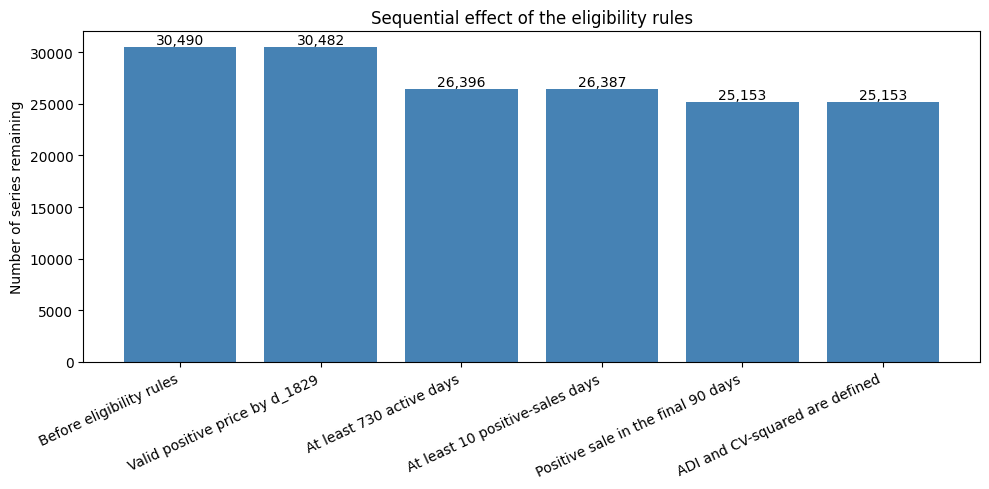

In [78]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    sequential_table["step"],
    sequential_table["number_remaining"],
    color="steelblue",
)

plt.title(
    "Sequential effect of the eligibility rules"
)
plt.ylabel("Number of series remaining")
plt.xticks(rotation=25, ha="right")

for bar, value in zip(
    bars,
    sequential_table["number_remaining"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

### Save eligibility outputs

In [82]:
# Store eligibility and sensitivity outputs in the common Chapter 4 table directory.
individual_rule_table.to_csv(
    TABLE_DIR / "individual_rule_effects.csv",
    index=False,
)
sequential_table.to_csv(
    TABLE_DIR / "sequential_rule_effects.csv",
    index=False,
)
before_after_table.to_csv(
    TABLE_DIR / "before_after_comparison.csv",
    index=False,
)
failure_profile_table.to_csv(
    TABLE_DIR / "failure_profiles.csv",
    index=False,
)
sensitivity_table.to_csv(
    TABLE_DIR / "threshold_sensitivity.csv",
    index=False,
)
eligible_series.to_csv(
    TABLE_DIR / "eligible_series.csv",
    index=False,
)

print("Eligibility results saved in:")
print(TABLE_DIR.resolve())

Eligibility results saved in:
<CHAPTER4_OUTPUT_DIR>/tables


## Eligible series by demand class

In [86]:
class_order = [
    "Smooth",
    "Erratic",
    "Intermittent",
    "Lumpy",
]

class_results = []

for demand_class in class_order:

    all_class_series = series_statistics[
        series_statistics["demand_class"] == demand_class
    ]

    eligible_class_series = all_class_series[
        all_class_series["eligible"]
    ]

    number_before = len(all_class_series)
    number_eligible = len(eligible_class_series)

    class_results.append({
        "demand_class": demand_class,
        "classifiable_series_before_rules": number_before,
        "eligible_series": number_eligible,
        "excluded_series": number_before - number_eligible,
        "eligible_percent_within_class":
            100 * number_eligible / number_before,
        "enough_for_sample_of_125":
            number_eligible >= 125,
    })


eligible_class_table = pd.DataFrame(class_results)

print(eligible_class_table)

   demand_class  classifiable_series_before_rules  eligible_series  \
0        Smooth                              1861             1667   
1       Erratic                               864              823   
2  Intermittent                             22176            17841   
3         Lumpy                              5574             4822   

   excluded_series  eligible_percent_within_class  enough_for_sample_of_125  
0              194                      89.575497                      True  
1               41                      95.254630                      True  
2             4335                      80.451840                      True  
3              752                      86.508791                      True  


### Composition of the eligible population

In [90]:
eligible_class_table["percent_of_eligible_population"] = (
    100
    * eligible_class_table["eligible_series"]
    / eligible_class_table["eligible_series"].sum()
)

print(eligible_class_table)

   demand_class  classifiable_series_before_rules  eligible_series  \
0        Smooth                              1861             1667   
1       Erratic                               864              823   
2  Intermittent                             22176            17841   
3         Lumpy                              5574             4822   

   excluded_series  eligible_percent_within_class  enough_for_sample_of_125  \
0              194                      89.575497                      True   
1               41                      95.254630                      True   
2             4335                      80.451840                      True   
3              752                      86.508791                      True   

   percent_of_eligible_population  
0                        6.627440  
1                        3.271976  
2                       70.929909  
3                       19.170675  


### Eligible-series figure

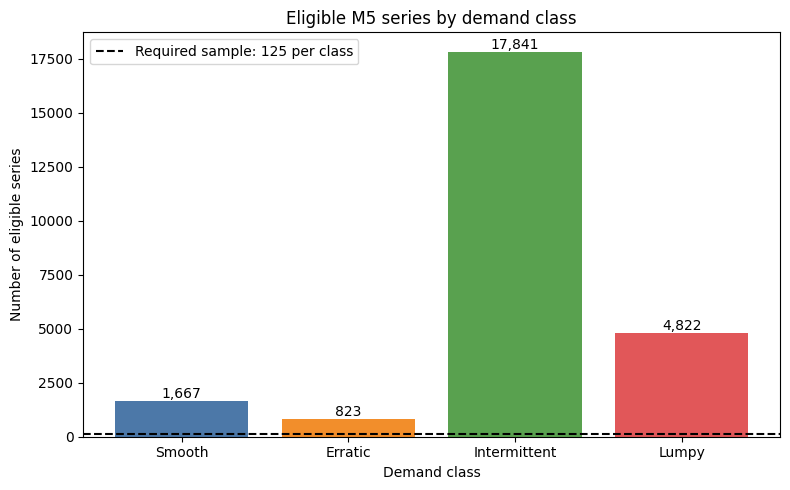

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.bar(
    eligible_class_table["demand_class"],
    eligible_class_table["eligible_series"],
    color=["#4C78A8", "#F28E2B", "#59A14F", "#E15759"],
)

plt.axhline(
    125,
    color="black",
    linestyle="--",
    label="Required sample: 125 per class",
)

plt.title("Eligible M5 series by demand class")
plt.xlabel("Demand class")
plt.ylabel("Number of eligible series")
plt.legend()

for bar, value in zip(
    bars,
    eligible_class_table["eligible_series"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

In [96]:
eligible_class_table.to_csv(
    TABLE_DIR / "eligible_series_by_demand_class.csv",
    index=False,
)

## Verify the frozen sample

In [102]:
pattern_names = [
    "smooth",
    "erratic",
    "intermittent",
    "lumpy",
]

# The distributed frozen sample is intentionally compact. Reconstruct the
# active-period metadata from the eligibility calculations above.
frozen_ids = pd.read_csv(SAMPLE_FILE)
if "demand_class" in frozen_ids.columns:
    frozen_class_column = "demand_class"
elif "demand_pattern" in frozen_ids.columns:
    frozen_class_column = "demand_pattern"
else:
    raise KeyError(
        "The frozen sample must contain 'demand_class' or 'demand_pattern'."
    )

requested_classes = frozen_ids[["id", frozen_class_column]].copy()
requested_classes = requested_classes.rename(
    columns={frozen_class_column: "requested_demand_class"}
)
requested_classes["requested_demand_class"] = (
    requested_classes["requested_demand_class"]
    .astype(str)
    .str.lower()
)

metadata_columns = [
    "id",
    "item_id",
    "store_id",
    "cat_id",
    "dept_id",
    "state_id",
    "row_number",
    "first_active_day",
    "active_days",
    "active_positive_days",
    "adi",
    "cv2_positive",
    "recent_positive_sale",
    "demand_class",
]
selected = requested_classes.merge(
    eligible_series[metadata_columns],
    on="id",
    how="left",
    validate="one_to_one",
)

if selected["row_number"].isna().any():
    missing_ids = selected.loc[
        selected["row_number"].isna(), "id"
    ].tolist()
    raise ValueError(
        "The frozen sample contains IDs that did not pass the eligibility "
        f"rules: {missing_ids[:10]}"
    )

selected["computed_demand_class"] = (
    selected["demand_class"].astype(str).str.lower()
)
assert (
    selected["requested_demand_class"]
    == selected["computed_demand_class"]
).all()

positive_means = []
positive_sds = []
recent_positive_sales = []
for _, row in selected.iterrows():
    row_number = int(row["row_number"])
    first_day = int(row["first_active_day"])
    active_values = sales_values[
        row_number,
        first_day - 1:SELECTION_END,
    ]
    positive_values = active_values[active_values > 0]
    positive_means.append(positive_values.mean())
    positive_sds.append(positive_values.std(ddof=1))
    recent_positive_sales.append(
        sales_values[
            row_number,
            recent_start - 1:SELECTION_END,
        ].sum()
    )

selected["positive_mean"] = positive_means
selected["positive_sd"] = positive_sds
selected["recent_positive_sales"] = recent_positive_sales
selected = selected.rename(
    columns={
        "active_positive_days": "positive_days",
        "adi": "ADI",
        "cv2_positive": "CV2_plus",
    }
)
selected["demand_class"] = pd.Categorical(
    selected["computed_demand_class"],
    categories=pattern_names,
    ordered=True,
)
selected = selected[
    [
        "id",
        "item_id",
        "store_id",
        "cat_id",
        "first_active_day",
        "active_days",
        "positive_days",
        "positive_mean",
        "positive_sd",
        "ADI",
        "CV2_plus",
        "recent_positive_sales",
        "demand_class",
        "row_number",
        "dept_id",
        "state_id",
    ]
]

sample_counts = (
    selected["demand_class"]
    .value_counts(sort=False)
    .reindex(pattern_names)
)
print(sample_counts)
assert len(selected) == 500
assert (sample_counts == 125).all()
print("The frozen sample was loaded and verified successfully.")

demand_class
smooth          125
erratic         125
intermittent    125
lumpy           125
Name: count, dtype: int64
The frozen sample was loaded and verified successfully.


In [105]:
# Input paths are defined in the setup cell.
SALES_PATH = DATA_DIR / "sales_train_evaluation.csv"
CALENDAR_PATH = DATA_DIR / "calendar.csv"
PRICES_PATH = DATA_DIR / "sell_prices.csv"

# ------------------------------------------------------------
# 1. General settings
# ------------------------------------------------------------

TRAIN_END = 1829

day_columns = [
    f"d_{day}"
    for day in range(1, TRAIN_END + 1)
]

pattern_names = [
    "smooth",
    "erratic",
    "intermittent",
    "lumpy",
]


# ------------------------------------------------------------
# 2. Load sales data through d_1829
# ------------------------------------------------------------

metadata_columns = [
    "id",
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",
]

sales_columns = (
    metadata_columns
    + day_columns
)

sales_dtypes = {
    day: "int16"
    for day in day_columns
}


sales = pd.read_csv(
    SALES_PATH,
    usecols=sales_columns,
    dtype=sales_dtypes,
)

# Save the original row position.
sales["row_number"] = np.arange(len(sales))

# Create the demand array used by the later calculations.
demand_array = sales[
    day_columns
].to_numpy(
    dtype=np.float32,
    copy=False,
)

print("Sales data loaded:", sales.shape)
print("Demand array:", demand_array.shape)

Sales data loaded: (30490, 1836)
Demand array: (30490, 1829)


In [106]:
# ------------------------------------------------------------
# 4. Load calendar and price data
# ------------------------------------------------------------

CALENDAR_FILE = pd.read_csv(
    CALENDAR_PATH
)

CALENDAR_FILE["date"] = pd.to_datetime(
    CALENDAR_FILE["date"]
)

CALENDAR_FILE["day_number"] = (
    CALENDAR_FILE["d"]
    .str.replace("d_", "", regex=False)
    .astype(int)
)


# The smaller calendar object contains only the selection period.
calendar = CALENDAR_FILE[
    CALENDAR_FILE["day_number"] <= TRAIN_END
].copy()


prices = pd.read_csv(
    PRICES_PATH,
    usecols=[
        "store_id",
        "item_id",
        "wm_yr_wk",
        "sell_price",
    ],
)

prices["sell_price"] = pd.to_numeric(
    prices["sell_price"],
    errors="coerce",
)

print("Calendar data loaded:", CALENDAR_FILE.shape)
print("Price data loaded:", prices.shape)

Calendar data loaded: (1969, 15)
Price data loaded: (6841121, 4)


In [108]:
# ------------------------------------------------------------
# 5. Load the frozen 500-series sample
# ------------------------------------------------------------

selected = pd.read_csv(
    SAMPLE_FILE
)

# Remove metadata that will be restored from the original sales file.
selected = selected.drop(
    columns=[
        "row_number",
        "dept_id",
        "state_id",
    ],
    errors="ignore",
)


selected = selected.merge(
    sales[
        [
            "id",
            "row_number",
            "dept_id",
            "state_id",
        ]
    ],
    on="id",
    how="left",
    validate="one_to_one",
)


selected["demand_class"] = pd.Categorical(
    selected["demand_class"],
    categories=pattern_names,
    ordered=True,
)


sample = selected.copy()

In [111]:
# ------------------------------------------------------------
# 6. Verification
# ------------------------------------------------------------

sample_counts = (
    sample["demand_class"]
    .value_counts(sort=False)
    .reindex(pattern_names)
)

print("\nSelected series by demand class:")
print(sample_counts)

print("\nTotal selected series:", len(sample))
print(
    "Missing row numbers:",
    sample["row_number"].isna().sum()
)
print(
    "Missing departments:",
    sample["dept_id"].isna().sum()
)
print(
    "Missing states:",
    sample["state_id"].isna().sum()
)


assert len(sample) == 500
assert (sample_counts == 125).all()
assert sample["row_number"].notna().all()
assert sample["dept_id"].notna().all()
assert sample["state_id"].notna().all()

print("\nAll required objects were loaded successfully.")


Selected series by demand class:
demand_class
smooth          125
erratic         125
intermittent    125
lumpy           125
Name: count, dtype: int64

Total selected series: 500
Missing row numbers: 0
Missing departments: 0
Missing states: 0

All required objects were loaded successfully.


In [113]:
print(sample.shape)
print(sample.columns)

(500, 16)
Index(['id', 'item_id', 'store_id', 'cat_id', 'first_active_day',
       'active_days', 'positive_days', 'positive_mean', 'positive_sd', 'ADI',
       'CV2_plus', 'recent_positive_sales', 'demand_class', 'row_number',
       'dept_id', 'state_id'],
      dtype='str')


## Sample composition

In [117]:
def create_composition_table(data, variable):

    table = pd.crosstab(
        data[variable],
        data["demand_class"]
    )

    table = table.reindex(
        columns=pattern_names,
        fill_value=0
    )

    table["total"] = table[pattern_names].sum(axis=1)

    table["percent_of_sample"] = (
        100 * table["total"] / len(data)
    )

    return table.reset_index()


category_composition = create_composition_table(
    sample,
    "cat_id"
)

state_composition = create_composition_table(
    sample,
    "state_id"
)

store_composition = create_composition_table(
    sample,
    "store_id"
)

department_composition = create_composition_table(
    sample,
    "dept_id"
)


print("\nComposition by category:")
print(category_composition)

print("\nComposition by state:")
print(state_composition)

print("\nComposition by store:")
print(store_composition)

print("\nComposition by department:")
print(department_composition)


Composition by category:
demand_class     cat_id  smooth  erratic  intermittent  lumpy  total  \
0                 FOODS      84       96            43     96    319   
1               HOBBIES       3        6            26     16     51   
2             HOUSEHOLD      38       23            56     13    130   

demand_class  percent_of_sample  
0                          63.8  
1                          10.2  
2                          26.0  

Composition by state:
demand_class state_id  smooth  erratic  intermittent  lumpy  total  \
0                  CA      57       54            51     43    205   
1                  TX      36       33            33     45    147   
2                  WI      32       38            41     37    148   

demand_class  percent_of_sample  
0                          41.0  
1                          29.4  
2                          29.6  

Composition by store:
demand_class store_id  smooth  erratic  intermittent  lumpy  total  \
0               

In [ ]:
category_composition.to_csv(
    TABLE_DIR / "sample_composition_by_category.csv",
    index=False
)

state_composition.to_csv(
    TABLE_DIR / "sample_composition_by_state.csv",
    index=False
)

store_composition.to_csv(
    TABLE_DIR / "sample_composition_by_store.csv",
    index=False
)

department_composition.to_csv(
    TABLE_DIR / "sample_composition_by_department.csv",
    index=False
)

## Descriptive statistics for the selected 500 series

In [122]:
sample_statistics_records = []


def classify_demand_again(adi, cv2_positive):

    if pd.isna(adi) or pd.isna(cv2_positive):
        return "unclassified"

    if adi < 1.32 and cv2_positive < 0.49:
        return "smooth"

    if adi < 1.32 and cv2_positive >= 0.49:
        return "erratic"

    if adi >= 1.32 and cv2_positive < 0.49:
        return "intermittent"

    return "lumpy"


for _, row in sample.iterrows():

    row_number = int(row["row_number"])
    first_active_day = int(row["first_active_day"])

    active_demand = demand_array[
        row_number,
        first_active_day - 1:TRAIN_END
    ]

    positive_demand = active_demand[
        active_demand > 0
    ]

    active_days = len(active_demand)
    positive_days = len(positive_demand)

    adi = active_days / positive_days

    positive_mean = positive_demand.mean()
    positive_sd = positive_demand.std(ddof=1)

    cv2_positive = (
        positive_sd / positive_mean
    ) ** 2

    sample_statistics_records.append({
        "id": row["id"],
        "item_id": row["item_id"],
        "store_id": row["store_id"],
        "state_id": row["state_id"],
        "cat_id": row["cat_id"],
        "dept_id": row["dept_id"],
        "demand_class": str(row["demand_class"]),

        "active_days": active_days,
        "total_sales": active_demand.sum(),
        "mean_daily_demand": active_demand.mean(),
        "demand_standard_deviation":
            active_demand.std(ddof=1),
        "maximum_daily_demand": active_demand.max(),

        "positive_days": positive_days,
        "zero_proportion":
            np.mean(active_demand == 0),

        "ADI": adi,
        "CV2_plus": cv2_positive,

        "recomputed_class":
            classify_demand_again(
                adi,
                cv2_positive
            ),
    })


sample_statistics = pd.DataFrame(
    sample_statistics_records
)

print(sample_statistics.head())

                            id      item_id store_id state_id cat_id  dept_id  \
0  FOODS_1_082_TX_1_evaluation  FOODS_1_082     TX_1       TX  FOODS  FOODS_1   
1  FOODS_1_085_WI_2_evaluation  FOODS_1_085     WI_2       WI  FOODS  FOODS_1   
2  FOODS_1_086_CA_2_evaluation  FOODS_1_086     CA_2       CA  FOODS  FOODS_1   
3  FOODS_1_170_TX_3_evaluation  FOODS_1_170     TX_3       TX  FOODS  FOODS_1   
4  FOODS_2_013_CA_2_evaluation  FOODS_2_013     CA_2       CA  FOODS  FOODS_2   

  demand_class  active_days  total_sales  mean_daily_demand  \
0       smooth         1059       5765.0           5.443815   
1       smooth         1829      20898.0          11.425916   
2       smooth         1829       6814.0           3.725533   
3       smooth         1738       8054.0           4.634062   
4       smooth         1829       7207.0           3.940405   

   demand_standard_deviation  maximum_daily_demand  positive_days  \
0                   5.239933                  34.0            815

In [124]:
class_matches = (
    sample_statistics["demand_class"]
    == sample_statistics["recomputed_class"]
)

print(
    "Correctly reproduced classes:",
    class_matches.sum(),
    "out of",
    len(class_matches)
)

assert class_matches.all()

Correctly reproduced classes: 500 out of 500


In [ ]:
sample_statistics.to_csv(
    TABLE_DIR / "selected_sample_series_statistics.csv",
    index=False
)

### Median and interquartile-range tables

In [151]:
sample_statistics["zero_sales_percent"] = (
    100 * sample_statistics["zero_proportion"]
)


def median_and_iqr(values):

    median = values.median()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    return f"{median:.2f} [{q1:.2f}, {q3:.2f}]"


def create_descriptive_table(metric_information):

    rows = []

    groups = [
        ("Overall", sample_statistics)
    ]

    for demand_class in pattern_names:

        class_data = sample_statistics[
            sample_statistics["demand_class"]
            == demand_class
        ]

        groups.append(
            (demand_class.capitalize(), class_data)
        )

    for group_name, group_data in groups:

        result = {"group": group_name}

        for column, label in metric_information.items():

            result[label] = median_and_iqr(
                group_data[column]
            )

        rows.append(result)

    return pd.DataFrame(rows)

In [153]:
# History, demand frequency and classification statistics

occurrence_metrics = {
    "active_days": "Active days",
    "positive_days": "Positive-sales days",
    "zero_sales_percent": "Zero-sales days (%)",
    "ADI": "ADI",
    "CV2_plus": "CV-squared positive",
}

occurrence_summary = create_descriptive_table(
    occurrence_metrics
)

print("\nDemand-occurrence statistics:")
print(occurrence_summary)

occurrence_summary.to_csv(
    TABLE_DIR / "sample_demand_occurrence_summary.csv",
    index=False
)


Demand-occurrence statistics:
          group                 Active days         Positive-sales days  \
0       Overall  1829.00 [1365.25, 1829.00]    990.00 [567.25, 1425.00]   
1        Smooth  1829.00 [1304.00, 1829.00]  1438.00 [1117.00, 1577.00]   
2       Erratic  1829.00 [1374.00, 1829.00]  1403.00 [1170.00, 1494.00]   
3  Intermittent  1787.00 [1374.00, 1829.00]     441.00 [267.00, 695.00]   
4         Lumpy  1829.00 [1402.00, 1829.00]     699.00 [459.00, 954.00]   

    Zero-sales days (%)                ADI CV-squared positive  
0  24.28 [16.84, 63.37]  1.32 [1.20, 2.73]   0.49 [0.36, 0.62]  
1  15.42 [10.50, 20.04]  1.18 [1.12, 1.25]   0.38 [0.34, 0.42]  
2  18.48 [14.54, 21.60]  1.23 [1.17, 1.28]   0.62 [0.53, 0.76]  
3  71.69 [55.60, 83.53]  3.53 [2.25, 6.07]   0.28 [0.17, 0.39]  
4  53.62 [41.88, 70.76]  2.16 [1.72, 3.42]   0.63 [0.54, 0.75]  


In [155]:
# Demand-volume statistics

magnitude_metrics = {
    "total_sales": "Total sales",
    "mean_daily_demand": "Mean daily demand",
    "demand_standard_deviation":
        "Daily-demand standard deviation",
    "maximum_daily_demand":
        "Maximum daily demand",
}

magnitude_summary = create_descriptive_table(
    magnitude_metrics
)

print("\nDemand-magnitude statistics:")
print(magnitude_summary)

magnitude_summary.to_csv(
    TABLE_DIR / "sample_demand_magnitude_summary.csv",
    index=False
)


Demand-magnitude statistics:
          group                  Total sales  Mean daily demand  \
0       Overall   3527.50 [1039.25, 7795.00]  2.45 [0.68, 4.93]   
1        Smooth  6379.00 [4177.00, 11222.00]  3.71 [2.78, 6.93]   
2       Erratic  8579.00 [5601.00, 12166.00]  5.38 [3.79, 7.04]   
3  Intermittent     600.00 [341.00, 1261.00]  0.41 [0.20, 0.84]   
4         Lumpy    1752.00 [890.00, 3078.00]  1.07 [0.59, 1.93]   

  Daily-demand standard deviation  Maximum daily demand  
0               2.42 [1.20, 4.61]  18.50 [11.00, 39.00]  
1               3.03 [2.35, 5.12]  22.00 [16.00, 36.00]  
2               5.29 [3.85, 7.16]  43.00 [31.00, 66.00]  
3               0.75 [0.51, 1.13]     6.00 [4.00, 9.00]  
4               1.63 [1.27, 2.78]  16.00 [13.00, 30.00]  


### Numerical median and interquartile-range results

In [159]:
# %% Numerical median and IQR results

all_metrics = {
    **occurrence_metrics,
    **magnitude_metrics,
}

numeric_summary_records = []

groups = [("Overall", sample_statistics)]

for demand_class in pattern_names:

    class_data = sample_statistics[
        sample_statistics["demand_class"]
        == demand_class
    ]

    groups.append(
        (demand_class.capitalize(), class_data)
    )


for group_name, group_data in groups:

    for column, label in all_metrics.items():

        numeric_summary_records.append({
            "group": group_name,
            "measure": label,
            "median": group_data[column].median(),
            "first_quartile":
                group_data[column].quantile(0.25),
            "third_quartile":
                group_data[column].quantile(0.75),
        })


numeric_summary = pd.DataFrame(
    numeric_summary_records
)

numeric_summary.to_csv(
    TABLE_DIR / "sample_descriptive_statistics_numeric.csv",
    index=False
)

### ADI–CV² classification figure

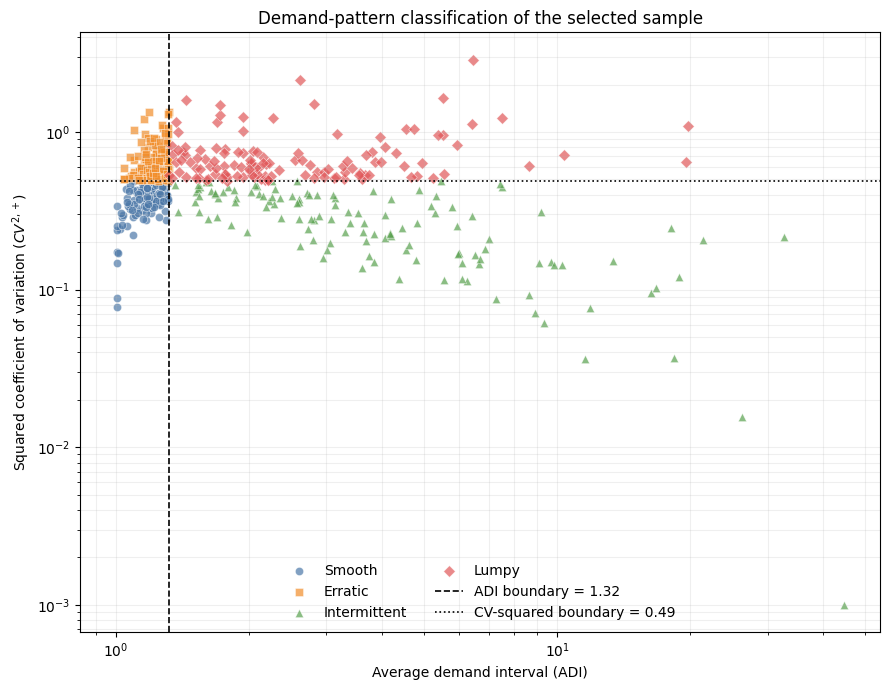

In [163]:
# %% ADI-CV-squared classification graph

plot_data = sample_statistics.copy()

# A logarithmic scale makes strongly skewed values easier to see.
# Exact zeros are shown at 0.001 only for visualisation.
plot_data["CV2_for_plot"] = (
    plot_data["CV2_plus"]
    .clip(lower=0.001)
)


colours = {
    "smooth": "#4C78A8",
    "erratic": "#F28E2B",
    "intermittent": "#59A14F",
    "lumpy": "#E15759",
}

markers = {
    "smooth": "o",
    "erratic": "s",
    "intermittent": "^",
    "lumpy": "D",
}


fig, ax = plt.subplots(figsize=(9, 7))


for demand_class in pattern_names:

    class_data = plot_data[
        plot_data["demand_class"]
        == demand_class
    ]

    ax.scatter(
        class_data["ADI"],
        class_data["CV2_for_plot"],
        label=demand_class.capitalize(),
        color=colours[demand_class],
        marker=markers[demand_class],
        alpha=0.70,
        s=35,
        edgecolor="white",
        linewidth=0.4,
    )


# Classification boundaries
ax.axvline(
    1.32,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="ADI boundary = 1.32",
)

ax.axhline(
    0.49,
    color="black",
    linestyle=":",
    linewidth=1.2,
    label="CV-squared boundary = 0.49",
)


ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title(
    "Demand-pattern classification of the selected sample"
)

ax.set_xlabel("Average demand interval (ADI)")
ax.set_ylabel(
    r"Squared coefficient of variation ($CV^{2,+}$)"
)

ax.grid(
    True,
    which="both",
    alpha=0.20
)

ax.legend(
    frameon=False,
    ncol=2
)

fig.tight_layout()


fig.savefig(
    FIGURE_DIR / "adi_cv2_selected_sample.pdf",
    bbox_inches="tight"
)

fig.savefig(
    FIGURE_DIR / "adi_cv2_selected_sample.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Price statistics for the selected sample

In [167]:
# %% Prepare price observations through d_1829

prices["sell_price"] = pd.to_numeric(
    prices["sell_price"],
    errors="coerce"
)

selection_weeks = (
    calendar["wm_yr_wk"]
    .dropna()
    .unique()
)

sample_keys = sample[
    [
        "id",
        "item_id",
        "store_id",
        "demand_class",
        "first_active_day",
    ]
].copy()


sample_prices = prices[
    prices["wm_yr_wk"].isin(selection_weeks)
    & prices["sell_price"].notna()
    & (prices["sell_price"] > 0)
].merge(
    sample_keys,
    on=["store_id", "item_id"],
    how="inner"
)


sample_prices = sample_prices.sort_values(
    ["id", "wm_yr_wk"]
)

In [169]:
price_statistics = (
    sample_prices
    .groupby(
        [
            "id",
            "demand_class",
            "store_id",
            "item_id",
        ],
        observed=True,
        as_index=False
    )
    .agg(
        observed_price_weeks=(
            "wm_yr_wk",
            "nunique"
        ),
        mean_price=(
            "sell_price",
            "mean"
        ),
        median_price=(
            "sell_price",
            "median"
        ),
        minimum_price=(
            "sell_price",
            "min"
        ),
        maximum_price=(
            "sell_price",
            "max"
        ),
        price_standard_deviation=(
            "sell_price",
            "std"
        ),
        number_of_price_changes=(
            "sell_price",
            lambda values:
                values.diff()
                .dropna()
                .ne(0)
                .sum()
        ),
    )
)

price_statistics["price_range"] = (
    price_statistics["maximum_price"]
    - price_statistics["minimum_price"]
)

price_statistics["price_cv"] = (
    price_statistics["price_standard_deviation"]
    / price_statistics["mean_price"]
)

In [171]:
# First and last day of every M5 week.

week_boundaries = (
    calendar
    .groupby("wm_yr_wk", as_index=False)
    .agg(
        week_first_day=("day_number", "min"),
        week_last_day=("day_number", "max"),
    )
)


expected_week_records = []

for _, row in sample.iterrows():

    first_active_day = int(
        row["first_active_day"]
    )

    expected_active_weeks = (
        week_boundaries["week_last_day"]
        >= first_active_day
    ).sum()

    expected_week_records.append({
        "id": row["id"],
        "expected_active_weeks":
            expected_active_weeks,
    })


expected_weeks = pd.DataFrame(
    expected_week_records
)


price_statistics = price_statistics.merge(
    expected_weeks,
    on="id",
    how="left"
)

price_statistics["price_coverage_percent"] = (
    100
    * price_statistics["observed_price_weeks"]
    / price_statistics["expected_active_weeks"]
)

print(price_statistics.head())

                            id  demand_class store_id      item_id  \
0  FOODS_1_005_WI_1_evaluation         lumpy     WI_1  FOODS_1_005   
1  FOODS_1_010_WI_1_evaluation  intermittent     WI_1  FOODS_1_010   
2  FOODS_1_012_WI_3_evaluation         lumpy     WI_3  FOODS_1_012   
3  FOODS_1_015_WI_2_evaluation         lumpy     WI_2  FOODS_1_015   
4  FOODS_1_018_CA_2_evaluation       erratic     CA_2  FOODS_1_018   

   observed_price_weeks  mean_price  median_price  minimum_price  \
0                   262    3.318779          3.28           2.94   
1                   188    6.992766          6.96           6.79   
2                   236    7.225763          7.03           6.79   
3                   253    3.215613          3.24           2.48   
4                   262    0.981603          0.98           0.98   

   maximum_price  price_standard_deviation  number_of_price_changes  \
0           3.54                  0.176856                        2   
1           7.27            

### Price summaries by demand class

In [174]:
# %% Price summary

price_metrics = {
    "observed_price_weeks":
        "Observed price weeks",

    "price_coverage_percent":
        "Price coverage (%)",

    "median_price":
        "Median selling price",

    "number_of_price_changes":
        "Number of price changes",

    "price_range":
        "Price range",
}


def create_price_summary():

    rows = []

    groups = [("Overall", price_statistics)]

    for demand_class in pattern_names:

        group_data = price_statistics[
            price_statistics["demand_class"]
            == demand_class
        ]

        groups.append(
            (demand_class.capitalize(), group_data)
        )

    for group_name, group_data in groups:

        row = {"group": group_name}

        for column, label in price_metrics.items():

            row[label] = median_and_iqr(
                group_data[column]
            )

        rows.append(row)

    return pd.DataFrame(rows)


price_summary = create_price_summary()

print(price_summary)

price_statistics.to_csv(
    TABLE_DIR / "selected_sample_price_statistics.csv",
    index=False
)

price_summary.to_csv(
    TABLE_DIR / "selected_sample_price_summary.csv",
    index=False
)

          group     Observed price weeks       Price coverage (%)  \
0       Overall  262.00 [195.75, 262.00]  100.00 [100.00, 100.00]   
1        Smooth  262.00 [187.00, 262.00]  100.00 [100.00, 100.00]   
2       Erratic  262.00 [197.00, 262.00]  100.00 [100.00, 100.00]   
3  Intermittent  256.00 [197.00, 262.00]  100.00 [100.00, 100.00]   
4         Lumpy  262.00 [201.00, 262.00]  100.00 [100.00, 100.00]   

  Median selling price Number of price changes        Price range  
0    2.38 [1.18, 3.97]       2.00 [1.00, 4.00]  0.21 [0.02, 0.54]  
1    2.00 [1.48, 3.47]       2.00 [1.00, 3.00]  0.20 [0.02, 0.47]  
2    1.00 [0.98, 2.18]       2.00 [0.00, 6.00]  0.08 [0.00, 0.34]  
3    3.98 [2.83, 6.97]       2.00 [1.00, 3.00]  0.44 [0.05, 0.79]  
4    2.24 [1.38, 3.24]       3.00 [1.00, 6.00]  0.30 [0.04, 0.70]  


## Calendar, event and SNAP summary

In [178]:
# %% Calendar information through d_1829

calendar_full = CALENDAR_FILE.copy()

calendar_full["day_number"] = (
    calendar_full["d"]
    .str.replace("d_", "", regex=False)
    .astype(int)
)

calendar_selection = calendar_full[
    calendar_full["day_number"] <= TRAIN_END
].copy()


event_columns = [
    column
    for column in [
        "event_name_1",
        "event_name_2",
    ]
    if column in calendar_selection.columns
]


calendar_selection["has_event"] = (
    calendar_selection[event_columns]
    .notna()
    .any(axis=1)
)


all_event_names = pd.concat(
    [
        calendar_selection[column]
        for column in event_columns
    ],
    ignore_index=True
).dropna()


calendar_summary = pd.DataFrame({
    "measure": [
        "Calendar days in the selection period",
        "Days containing at least one event",
        "Percentage of event days",
        "Number of different event names",
    ],
    "value": [
        len(calendar_selection),
        calendar_selection["has_event"].sum(),
        100 * calendar_selection["has_event"].mean(),
        all_event_names.nunique(),
    ],
})


print(calendar_summary)

calendar_summary.to_csv(
    TABLE_DIR / "calendar_event_summary.csv",
    index=False
)

                                 measure        value
0  Calendar days in the selection period  1829.000000
1     Days containing at least one event   146.000000
2               Percentage of event days     7.982504
3        Number of different event names    30.000000


In [180]:
# %% SNAP availability by state

snap_records = []

for state in ["CA", "TX", "WI"]:

    snap_column = f"snap_{state}"

    snap_days = (
        calendar_selection[snap_column] == 1
    ).sum()

    snap_records.append({
        "state": state,
        "selection_days":
            len(calendar_selection),
        "SNAP_days":
            snap_days,
        "SNAP_day_percentage":
            100
            * snap_days
            / len(calendar_selection),
    })


snap_summary = pd.DataFrame(
    snap_records
)

print(snap_summary)

snap_summary.to_csv(
    TABLE_DIR / "snap_calendar_summary.csv",
    index=False
)

  state  selection_days  SNAP_days  SNAP_day_percentage
0    CA            1829        600            32.804811
1    TX            1829        600            32.804811
2    WI            1829        600            32.804811


In [183]:
# %% Final output check

required_outputs = [
    TABLE_DIR / "sample_composition_by_category.csv",
    TABLE_DIR / "sample_composition_by_state.csv",
    TABLE_DIR / "sample_composition_by_store.csv",
    TABLE_DIR / "sample_composition_by_department.csv",
    TABLE_DIR / "selected_sample_series_statistics.csv",
    TABLE_DIR / "sample_demand_occurrence_summary.csv",
    TABLE_DIR / "sample_demand_magnitude_summary.csv",
    TABLE_DIR / "selected_sample_price_summary.csv",
    TABLE_DIR / "calendar_event_summary.csv",
    TABLE_DIR / "snap_calendar_summary.csv",
    FIGURE_DIR / "adi_cv2_selected_sample.pdf",
    FIGURE_DIR / "adi_cv2_selected_sample.png",
]

for output in required_outputs:

    print(
        output.name,
        "OK" if output.exists() else "MISSING"
    )

sample_composition_by_category.csv OK
sample_composition_by_state.csv OK
sample_composition_by_store.csv OK
sample_composition_by_department.csv OK
selected_sample_series_statistics.csv OK
sample_demand_occurrence_summary.csv OK
sample_demand_magnitude_summary.csv OK
selected_sample_price_summary.csv OK
calendar_event_summary.csv OK
snap_calendar_summary.csv OK
adi_cv2_selected_sample.pdf OK
adi_cv2_selected_sample.png OK
